In [1]:
%env DB_PASSWORD=5J8DhII0RRsPW1

env: DB_PASSWORD=5J8DhII0RRsPW1


In [28]:
import pandas as pd
import re
from constants.db_connections import ENGINE_READ_ONLY
import os
import paramiko
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


pd.reset_option('display.float_format')

In [71]:

# Set your server details
hostname = 'dandyweb01fl'  # Replace with your server's IP or hostname
port = 22                       # Usually 22 for SSH
username = 'glj523'      # Replace with your username
password = 'Wtcantfw36c!123'      # Replace with your password

remote_directories = ['/datasets/caeg_fastq/2023/20230927_A00706_0773_AHNLW5DSX5_AOZCK/eDNALib060-Kurt',
                      '/datasets/caeg_fastq/2023/20230927_A00706_0773_AHNLW5DSX5_AOZCK/eDNALib060-Thorfinn',
                      '/datasets/caeg_fastq/2024/20240702_A00706_0862_BH5F5KDSX7_WBDQ4_new/ssDNALib0019']

lib_ids_all = {}

remote_directory = remote_directories[0]  # Replace with the directory you want to list


# Create an SSH client
ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())

try:
    # Connect to the server
    ssh.connect(hostname, port, username, password)

    # Run the command to list files and directories

    for dir in remote_directories:
    
        stdin, stdout, stderr = ssh.exec_command(f"ls {dir} | grep '\.fastq.*$'")

        _, test, _ = ssh.exec_command(f"ls {dir} | grep '\.fastq.*$' | wc -l")
    

        # Process the output
        file_names = stdout.read().decode().splitlines()
        test = test.read().decode()

        lib_ids = [file_name.split("-")[0] for file_name in file_names]

        if int(test) != len(lib_ids):
            raise Exception("Error")

        lib_ids_all[dir.split("/")[-1]] = list(set(lib_ids))
    

        # Print the first 8 letters of each file/directory name
   

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    # Close the connection
    ssh.close()

df_orig = pd.read_sql(sql='select * from test_1.mega_table_qc_split_mat', con=ENGINE_READ_ONLY)
abi_data = pd.read_csv(r"c:\Users\glj523\Downloads\CambodiaLibs - cambodia_libs.tsv", sep="\t")

In [60]:
def generate_similar_dataset(n_libraries=40, samples_per_library=4):
    datasets = []
    
    for dataset_num in range(3):
        data = []
        for i in range(n_libraries):
            library_id = f"LV{7008000000 + np.random.randint(0, 999999):09d}"
            
            # Base values for this library
            base_raw_sequences = np.random.randint(40000000, 110000000)
            base_trimmed_ratio = np.random.uniform(0.1, 0.2)  # 10-20% of raw sequences
            base_raw_gc = np.random.randint(48, 55)
            gc_shift = np.random.randint(-2, 4)  # GC content shift after trimming
            
            for j in range(samples_per_library):
                # Add some variation to the base values
                raw_sequences = int(base_raw_sequences * np.random.uniform(0.98, 1.02))
                trimmed_sequences = int(raw_sequences * base_trimmed_ratio * np.random.uniform(0.98, 1.02))
                raw_gc = base_raw_gc
                trimmed_gc = base_raw_gc + gc_shift
                
                data.append({
                    'library_id': library_id,
                    'fastqc_raw__Total Sequences': raw_sequences,
                    'fastqc_trimmed__Total Sequences': trimmed_sequences,
                    'fastqc_raw__%GC': raw_gc,
                    'fastqc_trimmed__%GC': trimmed_gc,
                    'fastp__insert_size': '',
                    'samtools_stats__reads_mapped': ''
                })
        
        df = pd.DataFrame(data)
        df.index = range(len(df))
        datasets.append(df)
    
    return datasets

In [74]:
kurt = lib_ids_all["eDNALib060-Kurt"]
thorf = lib_ids_all["eDNALib060-Thorfinn"]
sslib = lib_ids_all["ssDNALib0019"]

cols = ['library_id', 
        'qc_type',
        'sample_name',
        'fastqc_raw__Total Sequences',
        'fastqc_trimmed__Total Sequences',
        r'fastqc_raw__%GC',
        r'fastqc_trimmed__%GC',
        'fastp__insert_size',
        'samtools_stats__reads_mapped']

sslib_qc = df_orig[df_orig["library_id"].isin(sslib)][cols]
thorf_qc = df_orig[df_orig["library_id"].isin(thorf)][cols]
kurt_qc = df_orig[df_orig["library_id"].isin(kurt)][cols]

if sslib_qc["sample_name"].duplicated().sum() != 0:
    raise Exception()
if (sslib_qc["library_id"] + "_" + sslib_qc["qc_type"]).duplicated().sum() != 0:
    raise Exception()

qc_types_raw = ['L001_R1', 'L002_R1', 'L003_R1', 'L004_R1', 'L001_R2', 'L002_R2', 'L003_R2', 'L004_R2']
qc_types_collapsed = ['L001_collapsed', 'L002_collapsed', 'L003_collapsed','L004_collapsed']
qc_types_singleton = ['L001_singleton', 'L002_singleton', 'L003_singleton', 'L004_singleton']


In [ ]:
fake_data = generate_similar_dataset()

sslib_qc = sslib_qc[sslib_qc["qc_type"].isin(qc_types_raw)].drop(columns=["qc_type", "sample_name"])

# Load each CSV file, and add sequencing type and platform
file_paths = {
    'MiSeq_Double': fake_data[0],
    'MiSeq_Single': sslib_qc,
    'NextSeq_Double': fake_data[1],
    'NextSeq_Single': fake_data[2]
}

# Create an empty list to store DataFrames
dfs = []

for label, df in file_paths.items():
    df['Protocol'] = 'Double' if 'Double' in label else 'Single'
    df['Platform'] = 'MiSeq' if 'MiSeq' in label else 'NextSeq'
    dfs.append(df)

# Concatenate all DataFrames into a single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)


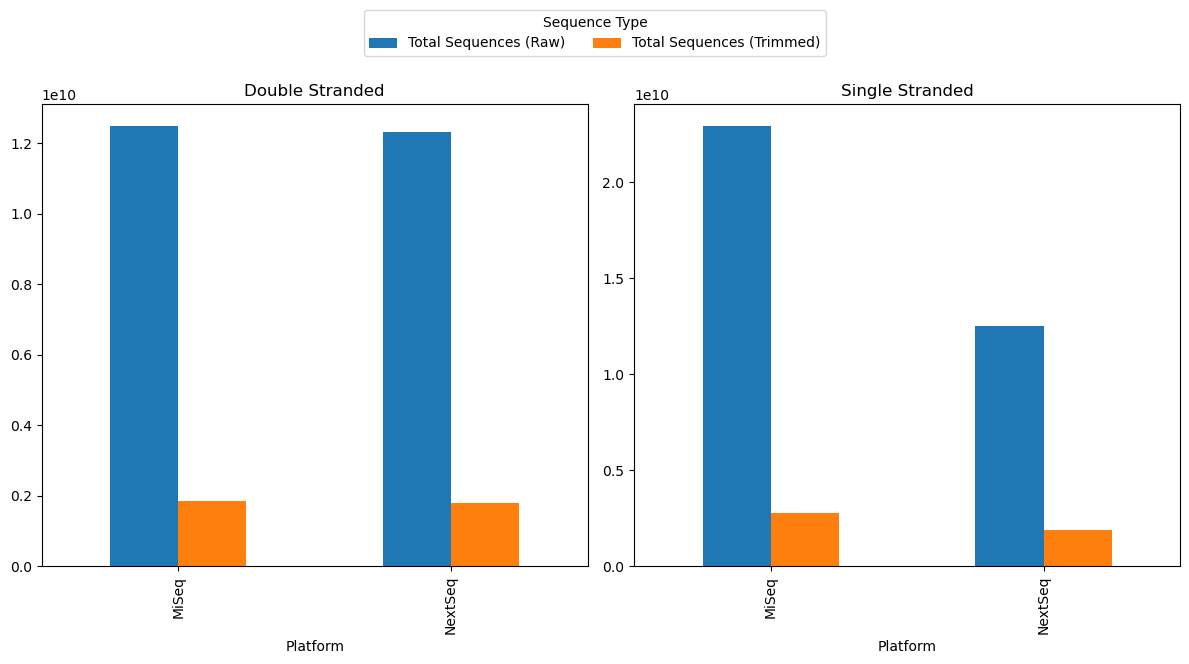

In [122]:
double_df = combined_df[combined_df['Protocol'] == 'Double']
single_df = combined_df[combined_df['Protocol'] == 'Single']

# Calculate mean values for each platform and each sequencing type
raw_sum_double = double_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()
trimmed_sum_double = double_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

raw_sum_single = single_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()
trimmed_sum_single = single_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

# Combine data into a DataFrame for easier plotting
combined_sums_double = pd.DataFrame({
    'Total Sequences (Raw)': raw_sum_double,
    'Total Sequences (Trimmed)': trimmed_sum_double
})

# Combine data into a DataFrame for easier plotting
combined_sums_single = pd.DataFrame({
    'Total Sequences (Raw)': raw_sum_single,
    'Total Sequences (Trimmed)': trimmed_sum_single
})

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
combined_sums_double.plot(kind='bar', ax=ax[0], title="Double Stranded", legend=False)
combined_sums_single.plot(kind='bar', ax=ax[1], title="Single Stranded", legend=False)

handles, labels = ax[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, title="Sequence Type")

plt.tight_layout()
plt.show()

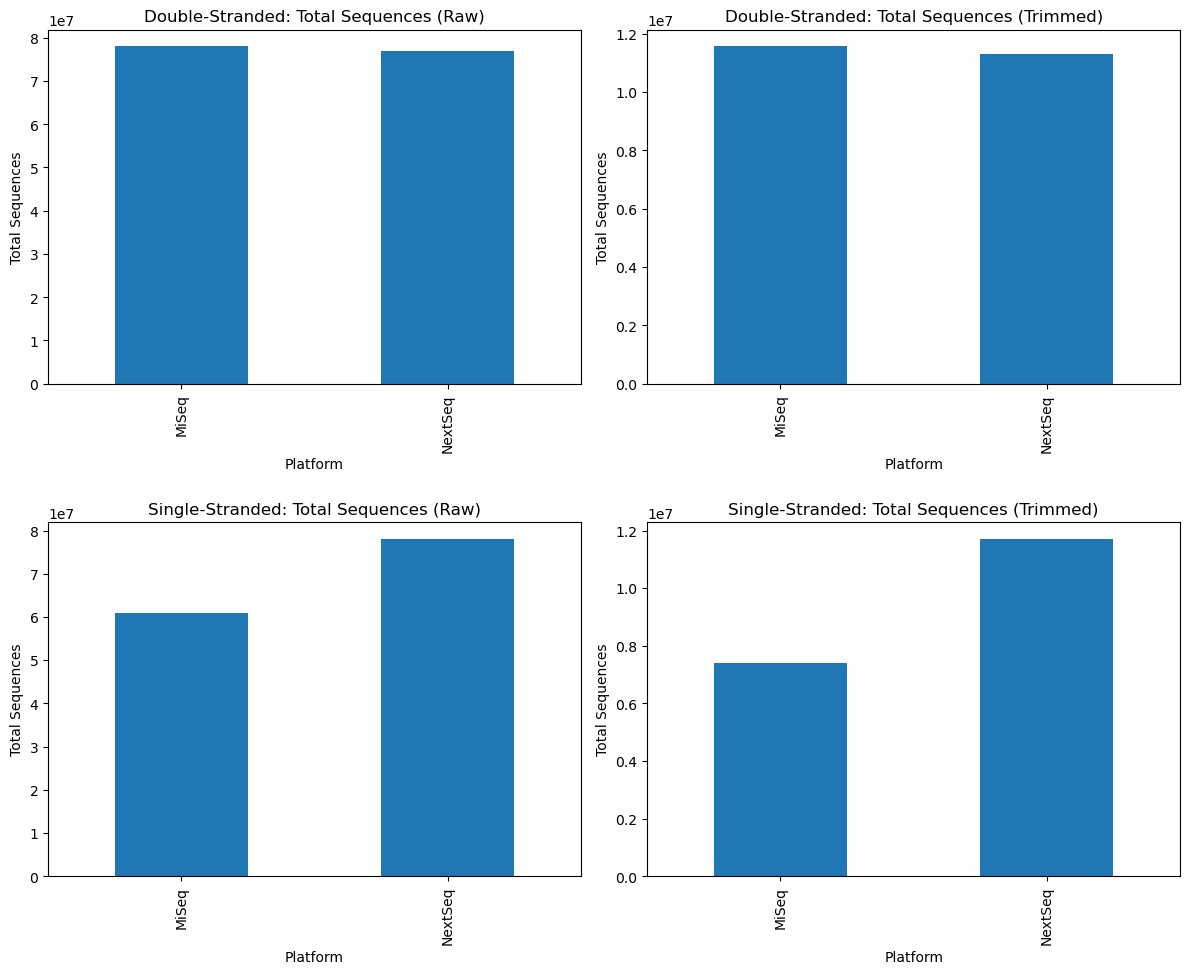

In [100]:
# Create subplots: one set for Double-stranded, one set for Single-stranded
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Filter DataFrames by sequencing type
double_df = combined_df[combined_df['Protocol'] == 'Double']
single_df = combined_df[combined_df['Protocol'] == 'Single']

# Double-stranded sequencing plots
double_df.groupby('Platform')['fastqc_raw__Total Sequences'].mean().plot(
    kind='bar', ax=axes[0, 0], title="Double-Stranded: Total Sequences (Raw)", ylabel="Total Sequences")
double_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].mean().plot(
    kind='bar', ax=axes[0, 1], title="Double-Stranded: Total Sequences (Trimmed)", ylabel="Total Sequences")

# Single-stranded sequencing plots
single_df.groupby('Platform')['fastqc_raw__Total Sequences'].mean().plot(
    kind='bar', ax=axes[1, 0], title="Single-Stranded: Total Sequences (Raw)", ylabel="Total Sequences")
single_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].mean().plot(
    kind='bar', ax=axes[1, 1], title="Single-Stranded: Total Sequences (Trimmed)", ylabel="Total Sequences")

# Adjust layout and show plots
plt.tight_layout()
plt.show()

C:\Users\glj523\AppData\Local\Temp\ipykernel_20524\101768575.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0].boxplot(
C:\Users\glj523\AppData\Local\Temp\ipykernel_20524\101768575.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1].boxplot(


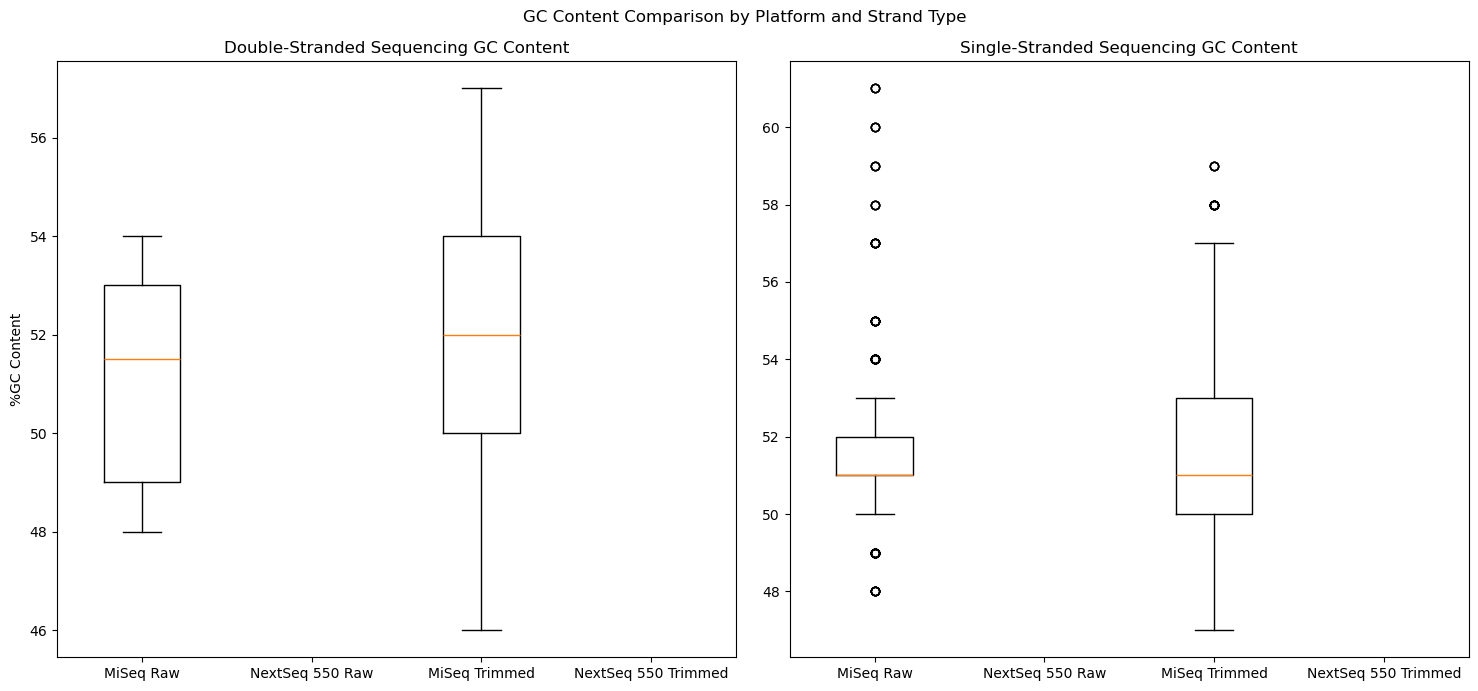

In [70]:
# Set up the plot
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Plot GC content for double-stranded sequencing
axs[0].boxplot(
    [double_df[double_df['Platform'] == 'MiSeq']['fastqc_raw__%GC'].dropna(),
     double_df[double_df['Platform'] == 'NextSeq 550']['fastqc_raw__%GC'].dropna(),
     double_df[double_df['Platform'] == 'MiSeq']['fastqc_trimmed__%GC'].dropna(),
     double_df[double_df['Platform'] == 'NextSeq 550']['fastqc_trimmed__%GC'].dropna()],
    labels=['MiSeq Raw', 'NextSeq 550 Raw', 'MiSeq Trimmed', 'NextSeq 550 Trimmed']
)
axs[0].set_title('Double-Stranded Sequencing GC Content')
axs[0].set_ylabel('%GC Content')

# Plot GC content for single-stranded sequencing
axs[1].boxplot(
    [single_df[single_df['Platform'] == 'MiSeq']['fastqc_raw__%GC'].dropna(),
     single_df[single_df['Platform'] == 'NextSeq 550']['fastqc_raw__%GC'].dropna(),
     single_df[single_df['Platform'] == 'MiSeq']['fastqc_trimmed__%GC'].dropna(),
     single_df[single_df['Platform'] == 'NextSeq 550']['fastqc_trimmed__%GC'].dropna()],
    labels=['MiSeq Raw', 'NextSeq 550 Raw', 'MiSeq Trimmed', 'NextSeq 550 Trimmed']
)
axs[1].set_title('Single-Stranded Sequencing GC Content')

# Display the plot
plt.suptitle('GC Content Comparison by Platform and Strand Type')
plt.tight_layout()
plt.show()

In [8]:
describe_cols = [r"fastqc_raw__%GC", r"fastqc_trimmed__%GC"]

In [9]:
def make_describe_plot(col, logy, data, include_count=False):
    for k, v in data.items():
        
        if include_count:
            data = {k: v[col].describe() for k, v in v.items()}
            
        else:
            data = {k: v[col].describe().iloc[1:] for k, v in v.items()}

        res = pd.DataFrame(data)
  
        res.plot(kind="bar", rot=30, logy=logy, title=k, ylabel=col)

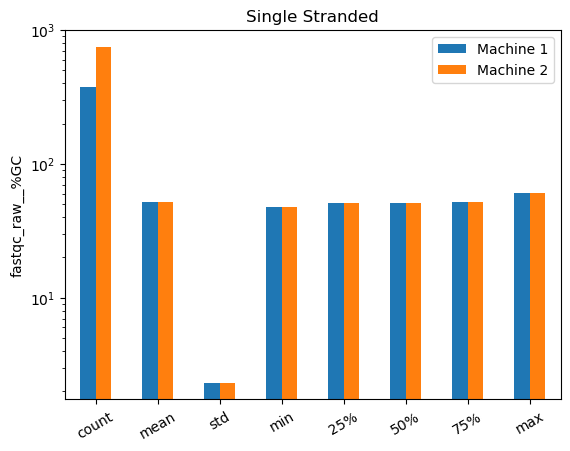

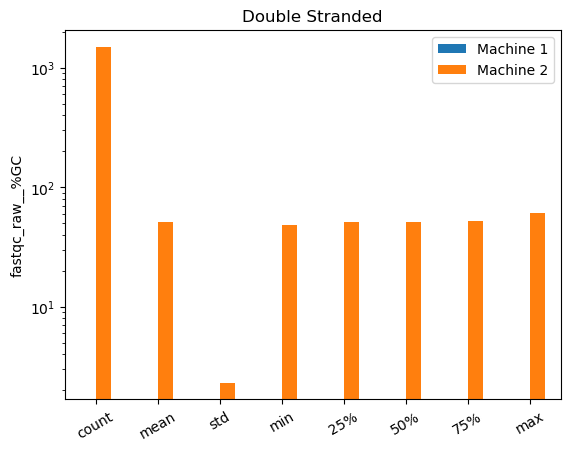

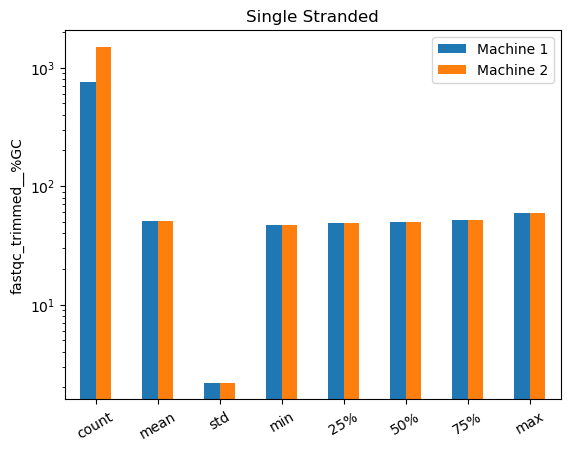

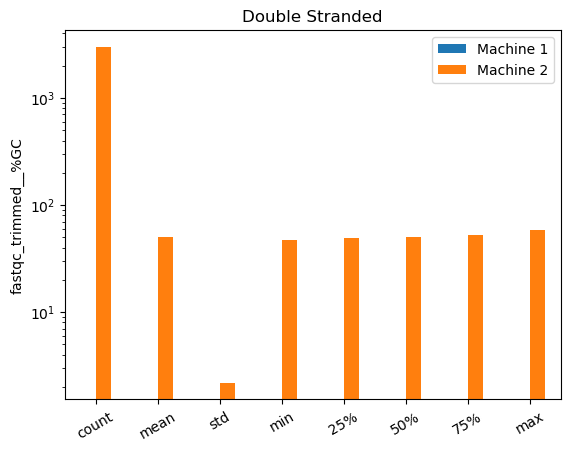

In [ ]:
machine_1_ss = sslib_qc
machine_2_ss = dummydata_1
machine_1_ds = pd.concat([thorf_qc, kurt_qc])
machine_2_ds = dummydata_3

data = {"Single Stranded": {"Machine 1": machine_1_ss,
                            "Machine 2": machine_2_ss},
        "Double Stranded": {"Machine 1": machine_1_ds,
                            "Machine 2": machine_2_ds}
        }

data = {"Single Stranded": {"Machine 1": df1,
                            "Machine 2": df2},
        "Double Stranded": {"Machine 1": df3,
                            "Machine 2": df4}
        }

for cols in describe_cols:

        make_describe_plot(cols, True, data, include_count=True)

Single Stranded
Double Stranded


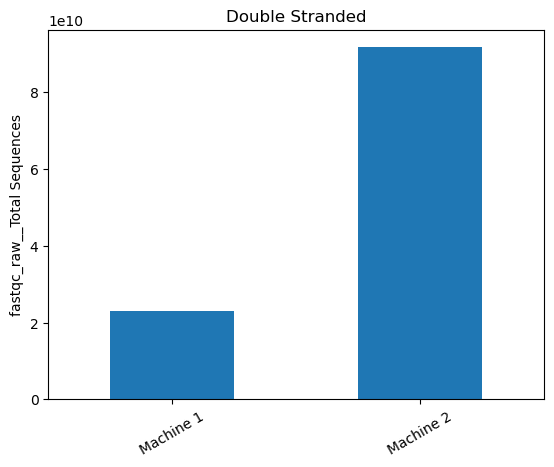

In [11]:

        
        
def make_sum_plot(col_to_sum, qc_types, logy):
        machine1_data = [thorf_qc, kurt_qc, sslib_qc]
        machine2_data = [thorf_qc, kurt_qc, sslib_qc]
        machine3_data = [thorf_qc, kurt_qc, sslib_qc]
        data_labels = ["thorfinn_data", "kurt_data", "ss_data"]


        data = {"Data": data_labels,
                "Machine 1": [df[df["qc_type"].isin(qc_types)][col_to_sum].sum() for df in machine1_data],
                "Machine 2": [df[df["qc_type"].isin(qc_types)][col_to_sum].sum() for df in machine2_data],
                "Machine 3": [df[df["qc_type"].isin(qc_types)][col_to_sum].sum() for df in machine3_data]}


        res = pd.DataFrame(data)
        return res.plot(kind="bar", x="Data", y=["Machine 1", "Machine 2", "Machine 3"], ylabel=col_to_sum, title=col_to_sum, rot=30, logy=logy)
    
    
def make_sum_plot(col, logy, data, include_count=False):
    
    
    for k, v in data.items():
        
        print(k)
    
        data = {k: v[col].sum() for k, v in v.items()}
        
        res = pd.Series(data)
  
        res.plot(kind="bar", rot=30, logy=logy, title=k, ylabel=col)

data_ = {"Single Stranded": {"Machine 1": machine_1_ss,
                            "Machine 2": machine_2_ss},
        "Double Stranded": {"Machine 1": machine_1_ds,
                            "Machine 2": machine_2_ds}
        }



make_sum_plot(sum_cols[0], False, data_)
        


In [12]:
data = {"Single Stranded": {"Machine 1": "machine_1_ss",
                            "Machine 2": "machine_2_ss"},
        "Double Stranded": {"Machine 1": "machine_1_ds",
                            "Machine 2": "machine_2_ds"}
        }

In [13]:
for k, v in data.items():
    print(k)
    print({k: v + "[col].sum()" for k, v in v.items()}
)

Single Stranded
{'Machine 1': 'machine_1_ss[col].sum()', 'Machine 2': 'machine_2_ss[col].sum()'}
Double Stranded
{'Machine 1': 'machine_1_ds[col].sum()', 'Machine 2': 'machine_2_ds[col].sum()'}


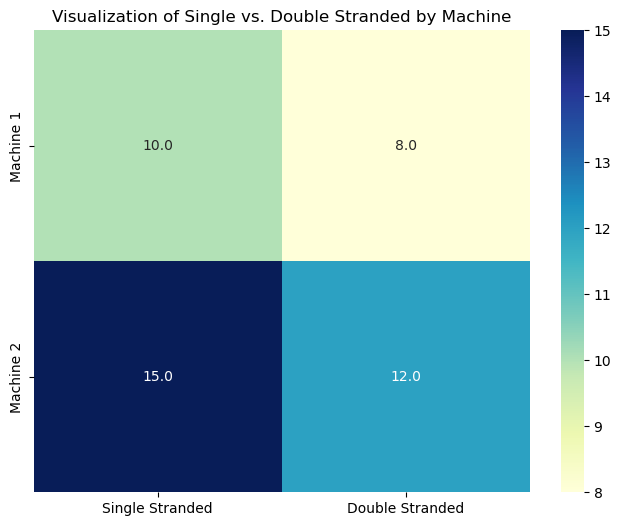

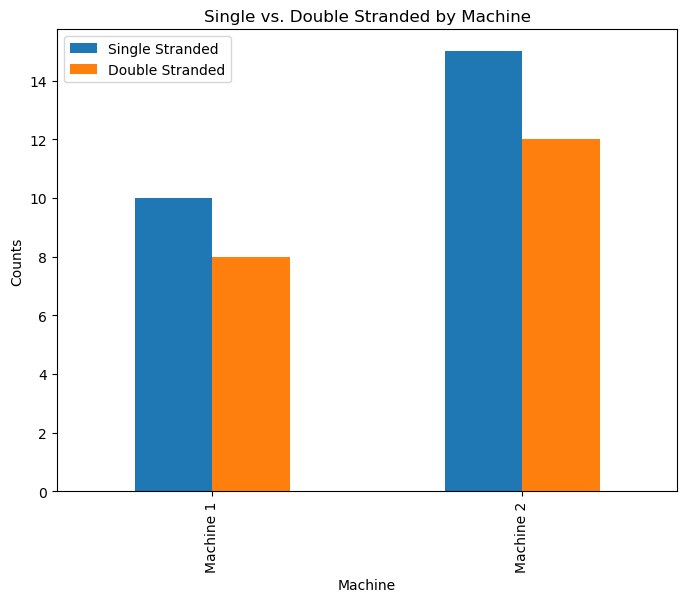

In [14]:
data_ = {
    "Single Stranded": {"Machine 1": 10, "Machine 2": 15},
    "Double Stranded": {"Machine 1": 8, "Machine 2": 12}
}

# Convert dictionary to DataFrame
df = pd.DataFrame(data_)

# Plot as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, cmap="YlGnBu", cbar=True, fmt=".1f")
plt.title("Visualization of Single vs. Double Stranded by Machine")
plt.show()

# Or alternatively, plot as bar plot
df.plot(kind="bar", figsize=(8, 6))
plt.title("Single vs. Double Stranded by Machine")
plt.xlabel("Machine")
plt.ylabel("Counts")
plt.show()